<a href="https://colab.research.google.com/github/venkata18167/CSA6301---THREAT-INTELLIGENCE-AND-NETWORK-SECURITY/blob/main/27_Simulating_the_ELK_Stack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Raw Logs

2026-08-03 10:00:01 INFO 192.168.1.10 Login Successful
2026-08-03 10:00:15 ERROR 192.168.1.20 Invalid Password
2026-08-03 10:01:05 WARNING 192.168.1.30 Multiple Login Attempts
2026-08-03 10:01:30 INFO 192.168.1.40 File Downloaded
2026-08-03 10:02:00 ERROR 192.168.1.20 Invalid Password
2026-08-03 10:02:45 INFO 192.168.1.50 User Logout
2026-08-03 10:03:20 ERROR 192.168.1.20 Invalid Password
2026-08-03 10:04:00 WARNING 192.168.1.30 Suspicious Activity
2026-08-03 10:05:10 INFO 192.168.1.60 Login Successful
2026-08-03 10:06:15 ERROR 192.168.1.10 Account Locked


Parsed Logs (Logstash)

             Timestamp Log Level    IP Address                  Message
0  2026-08-03 10:00:01      INFO  192.168.1.10         Login Successful
1  2026-08-03 10:00:15     ERROR  192.168.1.20         Invalid Password
2  2026-08-03 10:01:05   WARNING  192.168.1.30  Multiple Login Attempts
3  2026-08-03 10:01:30      INFO  192.168.1.40          File Downloaded
4  2026-08-03 10:02:00     ERROR  192.168.

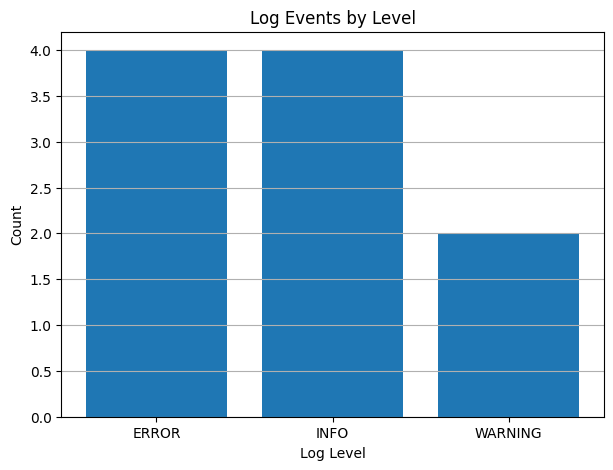


========== FINAL REPORT ==========
Total Logs : 10
INFO Logs : 4
WARNING Logs : 2
ERROR Logs : 4

ELK Stack Simulation Completed Successfully.


In [1]:
 import pandas as pd
import matplotlib.pyplot as plt
raw_logs = [

"2026-08-03 10:00:01 INFO 192.168.1.10 Login Successful",
"2026-08-03 10:00:15 ERROR 192.168.1.20 Invalid Password",
"2026-08-03 10:01:05 WARNING 192.168.1.30 Multiple Login Attempts",
"2026-08-03 10:01:30 INFO 192.168.1.40 File Downloaded",
"2026-08-03 10:02:00 ERROR 192.168.1.20 Invalid Password",
"2026-08-03 10:02:45 INFO 192.168.1.50 User Logout",
"2026-08-03 10:03:20 ERROR 192.168.1.20 Invalid Password",
"2026-08-03 10:04:00 WARNING 192.168.1.30 Suspicious Activity",
"2026-08-03 10:05:10 INFO 192.168.1.60 Login Successful",
"2026-08-03 10:06:15 ERROR 192.168.1.10 Account Locked"

]

print("Raw Logs\n")

for log in raw_logs:
    print(log)


records = []

for log in raw_logs:

    parts = log.split()

    timestamp = parts[0] + " " + parts[1]
    level = parts[2]
    ip = parts[3]
    message = " ".join(parts[4:])

    records.append([timestamp, level, ip, message])

logs = pd.DataFrame(records,
columns=[
"Timestamp",
"Log Level",
"IP Address",
"Message"
])

print("\n\nParsed Logs (Logstash)\n")
print(logs)


logs.to_csv("Elasticsearch_Index.csv",index=False)

print("\nLogs Indexed into Elasticsearch_Index.csv")

aggregation = logs.groupby("Log Level").size().reset_index(name="Count")

print("\nKibana Aggregation\n")
print(aggregation)

errors = logs[logs["Log Level"]=="ERROR"]

error_ip = errors.groupby("IP Address").size().reset_index(name="Error Count")

print("\nError Count by IP\n")
print(error_ip)

aggregation.to_csv("Kibana_Report.csv",index=False)
error_ip.to_csv("Error_Report.csv",index=False)

print("\nReports Saved Successfully.")

plt.figure(figsize=(7,5))

plt.bar(aggregation["Log Level"],
        aggregation["Count"])

plt.title("Log Events by Level")
plt.xlabel("Log Level")
plt.ylabel("Count")

plt.grid(axis='y')

plt.show()

print("\n========== FINAL REPORT ==========")

print("Total Logs :",len(logs))
print("INFO Logs :",len(logs[logs["Log Level"]=="INFO"]))
print("WARNING Logs :",len(logs[logs["Log Level"]=="WARNING"]))
print("ERROR Logs :",len(logs[logs["Log Level"]=="ERROR"]))

print("\nELK Stack Simulation Completed Successfully.")